### **ICESat数据处理**

In [ ]:
# mount on google drive
from google.colab import drive
drive.mount('/content/drive/')


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
import os
os.chdir('/content/drive/MyDrive/satellite-altimetry-course')


In [ ]:
# !pip install cartopy
# !pip install pyrsimg
# !apt-get install hdf5-tools


In [ ]:
import h5py
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from pyrsimg import readTiff, imgShow, second_to_dyr, geo2imagexy


In [ ]:
path_glah14 = 'data/laser/isat_gla_region.h5'
path_rsimg = 'data/rsimg/s2_gla_region_20220707.tif'
path_dem = 'data/srtm/SRTMGL1Ellip_gla_region.tif'
path_gla_vec = 'data/laser/gla_region.gpkg'


In [ ]:
!h5ls $path_glah14
# !h5ls $path_glah14/Data_1HZ/Geolocation/i_track
# !h5ls $path_glah14/Data_40HZ/Elevation_Surfaces


att_flg                  Dataset {212}
delta_ellip              Dataset {212}
elev                     Dataset {212}
elev_cor                 Dataset {212}
elev_dem                 Dataset {212}
elev_flg                 Dataset {212}
lat                      Dataset {212}
lon                      Dataset {212}
satu_corr                Dataset {212}
satu_flag                Dataset {212}
time                     Dataset {212}


In [ ]:
vars_glah14 = {}
with h5py.File(path_glah14,'r') as setp_glah14:
    vars_glah14['lat'] = setp_glah14['lat'][:]
    vars_glah14['lon'] = setp_glah14['lon'][:]
    vars_glah14['time'] = setp_glah14['time'][:]
    vars_glah14['elev_cor'] = setp_glah14['elev'][:]
    # vars_glah14['elev_dem'] = setp_glah14['elev_dem'][:]
    print(vars_glah14['lat'].shape)

## 2. remote sensing image
rsimg = readTiff(path_rsimg)
## 3. dem image
dem = readTiff(path_dem)
## 4. glacier region
gla_vec = gpd.read_file(path_gla_vec)


(212,)


### Time conversion

In [ ]:
### Apply time conversion (seconds to decimal year)
### Seconds (from 2000:00:00) to decimal year
print(vars_glah14['time'][0:10])
vars_glah14['time_dyr'] = second_to_dyr(vars_glah14['time'])
print(vars_glah14['time_dyr'][0:10])


[1.72389036e+08 1.72389036e+08 1.72389036e+08 1.72389037e+08
 1.72389037e+08 1.72389037e+08 1.72389037e+08 1.72389037e+08
 1.72389037e+08 1.72389037e+08]
[2005.46094205 2005.46094205 2005.46094205 2005.46094205 2005.46094205
 2005.46094205 2005.46094205 2005.46094205 2005.46094205 2005.46094206]


<Axes: >

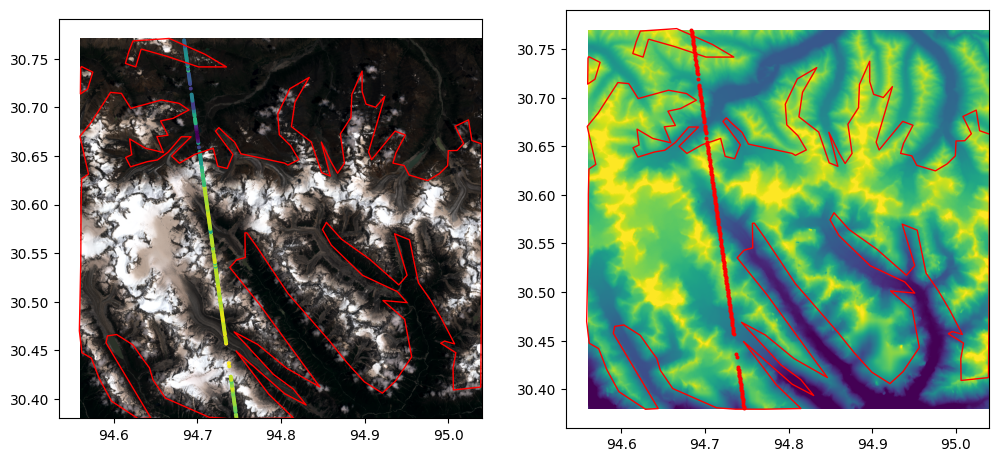

In [56]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
imgShow(rsimg.array, extent=rsimg.geoextent, per_band_clip=10, ax=ax[0])
ax[0].scatter(x=vars_glah14['lon'], y=vars_glah14['lat'], c=vars_glah14['elev_cor'], s=3.5)
imgShow(dem.array, extent=dem.geoextent, ax=ax[1])
ax[1].scatter(x=vars_glah14['lon'], y=vars_glah14['lat'], c='red', s=3.5)
gla_vec.plot(ax=ax[0], facecolor="none", edgecolor='red')
gla_vec.plot(ax=ax[1], facecolor="none", edgecolor='red')


In [ ]:
## 筛选出冰川点
ids_gla = np.zeros(shape=(vars_glah14['lon'].shape))
for i, lon in enumerate(vars_glah14['lon']):
    point = Point(lon, vars_glah14['lat'][i])
    if gla_vec.geometry[0].contains(point):
        ids_gla[i]=1
ids_gla


array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 0., 0., 0., 0.])

In [ ]:
row, col = geo2imagexy(x=vars_glah14['lon'], \
                         y=vars_glah14['lat'], \
                         gdal_trans=dem.geotrans, \
                         integer=True)
dem_isat_fp = dem.array[row, col]
dem_isat_fp[90:100]


array([4662.03417969, 4703.04003906, 4678.04296875, 4603.04589844,
       4559.04882812, 4465.05126953, 4354.0546875 , 4256.05712891,
       4131.06298828, 4088.06616211])

(94.68398099999999, 94.746596)

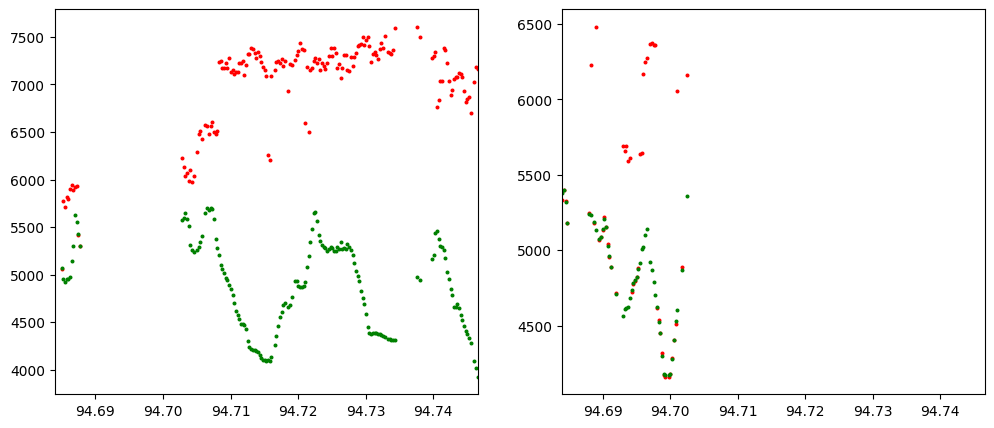

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12, 5))
ax[0].scatter(x=vars_glah14['lon'][ids_gla==1], y=vars_glah14['elev_cor'][ids_gla==1], c='red', s=3.5)  ## icesat data
ax[0].scatter(x=vars_glah14['lon'][ids_gla==1], y=dem_isat_fp[ids_gla==1], c='green', s=3.5)  ## srtm data
ax[0].set_xlim(min(vars_glah14['lon']), max(vars_glah14['lon']))
ax[1].scatter(x=vars_glah14['lon'][ids_gla==0], y=vars_glah14['elev_cor'][ids_gla==0], c='red', s=3.5)  ## icesat data
ax[1].scatter(x=vars_glah14['lon'][ids_gla==0], y=dem_isat_fp[ids_gla==0], c='green', s=3.5)  ## srtm data
ax[1].set_xlim(min(vars_glah14['lon']), max(vars_glah14['lon']))



## 冰川区域icesat高程与dem高程值间差异

In [ ]:
dif_ele = vars_glah14['elev_cor'] - dem_isat_fp
## 冰川区域
ids_gla_thre = np.where((ids_gla==1) & (abs(dif_ele)<150)) ## glacier region and elevation change < 150
dif_ele_gla = dif_ele[ids_gla_thre]
print(dif_ele_gla.mean())
## 非冰川区域
ids_stable_thre = np.where((ids_gla==0) & (abs(dif_ele)<50)) ## non-glacier region and elevation change < 50
dif_ele_stable = dif_ele[ids_stable_thre]
print(dif_ele_stable.mean())



-8.795735677083334
-1.9962797851561334


In [ ]:
dif_val_gla_cor = dif_ele_gla.mean()-dif_ele_stable.mean()
dif_val_gla_cor


-6.799455891927201

## 冰川消融速度

In [ ]:
gla_ele_change_rate = dif_val_gla_cor/(vars_glah14['time_dyr'][0]-2000)  ## srtm time is 2000/2/11
print(vars_glah14['time_dyr'][0])
print(gla_ele_change_rate)


2005.4609420474594
-1.2451067659819801


In [ ]:
### 标准差估算
sigma = np.std(dif_ele_stable)
print(sigma)


11.884284153094905
